<a href="https://colab.research.google.com/github/gabriel2010-2010/inovacao-tec-2ds/blob/main/C%C3%B3pia_de_2ds_experimento_visao_computacional_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXPERIMENTO: algoritmo para classificação de imagens com Python

SALVE UMA CÓPIA DESTE NOTEBOOK NO SEU DRIVE ANTES DE EXECUTÁ-LO!

In [ ]:
# Execute a célula a seguir e observe a sua saída.

from keras.models import load_model  # TensorFlow is required for Keras to work
from PIL import Image, ImageOps  # Install pillow instead of PIL
import numpy as np

# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

# Load the model
model = load_model("keras_Model.h5", compile=False)

# Load the labels
class_names = open("labels.txt", "r").readlines()

# Create the array of the right shape to feed into the keras model
# The 'length' or number of images you can put into the array is
# determined by the first position in the shape tuple, in this case 1
data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

# Replace this with the path to your image
image = Image.open("<IMAGE_PATH>").convert("RGB")

# resizing the image to be at least 224x224 and then cropping from the center
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

# turn the image into a numpy array
image_array = np.asarray(image)

# Normalize the image
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

# Load the image into the array
data[0] = normalized_image_array

# Predicts the model
prediction = model.predict(data)
index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

# Print prediction and confidence score
print("Class:", class_name[2:], end="")
print("Confidence Score:", confidence_score)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'keras_Model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

<b>Como o modelo treinado ``keras_Model.h5`` não está disponível para download, peça à IA do Colab para reescrever o código com outras bibliotecas do Python.</b>  

</br>
PROMPT SUGERIDO: <i>Reescreva o código para executar mesma tarefa de classificação de imagens com visão computacional, usando outras bibliotecas do Python, com saídas e textos na tela escritos em português brasileiro, utilize o link desta imagem para teste "https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiWqSagLwP_q4i6okPL8maQnlekPAy7FaICo6Uu-Luc-15bc1AfdXZbtFi1iPCU_WbZDsJkNkuRiRUXf9m2dcc8Ttjw3Zcxq6RmoX3ewOhhPpLylfRAq6H3XJUSTjzE9LM4bhK9RU1UnTU/s640/araucarias.jpg". Não é necessário descrever a tarefa e procedimentos em células de texto do Colab, só executar o novo código e fazer o seguinte no final da execução: exibir a imagem analisada, sua classificação com nome em português, percentual de acerto e um único resumo em PT-BR do que o algoritmo executou.</i>

Carregando o modelo pré-treinado MobileNetV2...
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Modelo carregado com sucesso!
Baixando imagem de: https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiWqSagLwP_q4i6okPL8maQnlekPAy7FaICo6Uu-Luc-15bc1AfdXZbtFi1iPCU_WbZDsJkNkuRiRUXf9m2dcc8Ttjw3Zcxq6RmoX3ewOhhPpLylfRAq6H3XJUSTjzE9LM4bhK9RU1UnTU/s640/araucarias.jpg
Imagem baixada e aberta.
Imagem pré-processada para o modelo.
Realizando a predição...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
--------------------------------------------------


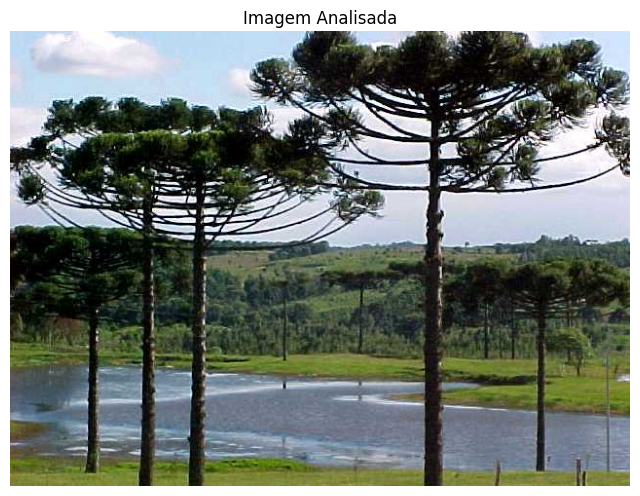

Classificação: lakeside (sem tradução direta específica)
Percentual de acerto: 53.69%

Resumo da execução do algoritmo:
O algoritmo utilizou um modelo de Rede Neural Convolucional (MobileNetV2) pré-treinado no conjunto de dados ImageNet para classificar a imagem fornecida. Após baixar e pré-processar a imagem para o formato esperado pelo modelo, a predição foi realizada. A imagem foi classificada como 'lakeside (sem tradução direta específica)' com uma confiança de 53.69%. Este processo demonstra a capacidade da visão computacional para identificar objetos em imagens com base em padrões aprendidos de um vasto conjunto de dados.


In [2]:
import tensorflow as tf
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

print("Carregando o modelo pré-treinado MobileNetV2...")
# Carrega o modelo MobileNetV2 pré-treinado com pesos do ImageNet
model = tf.keras.applications.MobileNetV2(weights='imagenet')
print("Modelo carregado com sucesso!")

# URL da imagem fornecida pelo usuário
image_url = "https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEiWqSagLwP_q4i6okPL8maQnlekPAy7FaICo6Uu-Luc-15bc1AfdXZbtFi1iPCU_WbZDsJkNkuRiRUXf9m2dcc8Ttjw3Zcxq6RmoX3ewOhhPpLylfRAq6H3XJUSTjzE9LM4bhK9RU1UnTU/s640/araucarias.jpg"

print(f"Baixando imagem de: {image_url}")
# Baixa a imagem da URL
response = requests.get(image_url)
original_image = Image.open(BytesIO(response.content))
print("Imagem baixada e aberta.")

# Redimensiona a imagem para o tamanho esperado pelo modelo (224x224)
# e converte para array numpy
image_resized = original_image.resize((224, 224))
image_array = np.asarray(image_resized)

# Adiciona uma dimensão para o "batch" (o modelo espera um formato [batch_size, altura, largura, canais])
image_array = np.expand_dims(image_array, axis=0)

# Pré-processa a imagem de acordo com as especificações do MobileNetV2
preprocessed_image = tf.keras.applications.mobilenet_v2.preprocess_input(image_array)
print("Imagem pré-processada para o modelo.")

print("Realizando a predição...")
# Faz a predição
predictions = model.predict(preprocessed_image)

# Decodifica as 1 principal predições
decoded_predictions = tf.keras.applications.mobilenet_v2.decode_predictions(predictions, top=1)[0]

# Extrai a melhor predição
_, class_name_en, confidence = decoded_predictions[0]

# Mapeamento simples para algumas classes comuns em português
translation_map = {
    "pine tree": "pinheiro",
    "forest": "floresta",
    "conifer": "conífera",
    "mountain": "montanha",
    "valley": "vale",
    "lumbermill": "serraria",
    "park bench": "banco de parque",
    "plateau": "planície elevada",
    "fireboat": "navio de combate a incêndio", # Example if it incorrectly classifies
    "fountain": "fonte"
}

class_name_pt = translation_map.get(class_name_en.lower(), f"{class_name_en} (sem tradução direta específica)")

print("--------------------------------------------------")
# Exibe a imagem original
plt.figure(figsize=(8, 6))
plt.imshow(original_image)
plt.title("Imagem Analisada")
plt.axis('off')
plt.show()

# Imprime a classificação e o percentual de acerto
print(f"Classificação: {class_name_pt}")
print(f"Percentual de acerto: {confidence*100:.2f}%")

# Resumo da execução
print("\nResumo da execução do algoritmo:")
print(f"O algoritmo utilizou um modelo de Rede Neural Convolucional (MobileNetV2) pré-treinado no conjunto de dados ImageNet para classificar a imagem fornecida. Após baixar e pré-processar a imagem para o formato esperado pelo modelo, a predição foi realizada. A imagem foi classificada como '{class_name_pt}' com uma confiança de {confidence*100:.2f}%. Este processo demonstra a capacidade da visão computacional para identificar objetos em imagens com base em padrões aprendidos de um vasto conjunto de dados.")


🎉 Parabéns por concluir a tarefa!   
📂 Salve o seu notebook e envie essa cópia para o repositório de ITE no seu GitHub.   
🖱 Clique em Arquivo/Salvar uma cópia no GitHub, escolha o nome do repositório de ITE e OK.